In [12]:
import matplotlib.pyplot as plt
import numpy as np

# https://wfdb-python.readthedocs.io/en/latest/index.html - работающая документация
import wfdb

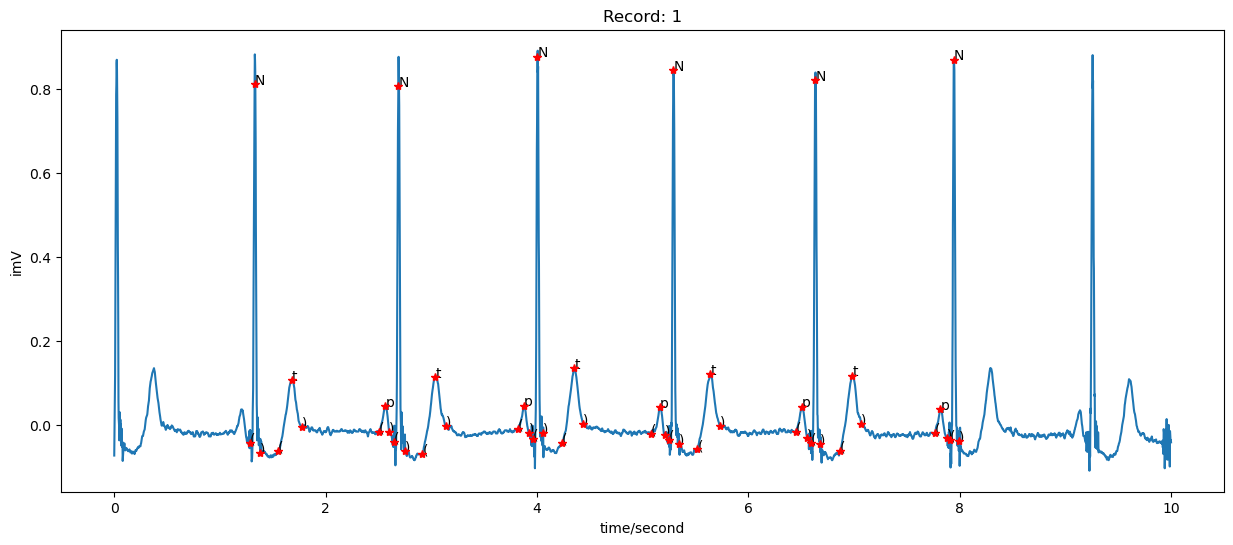

In [13]:
rec_path = 'physionet.org/files/ludb/1.0.1/data/1'

# порядок каналов можно узнать из .hea
record = wfdb.rdrecord(rec_path, channels=[0])

# i - для отведения I
ann = wfdb.rdann(rec_path, 'i')

# plot_sym - выводит лейблы аннотаций
wfdb.plot_wfdb(record=record, annotation=ann, figsize=(15,6), plot_sym=True)

In [14]:
record.comments

['<age>: 51',
 '<sex>: F',
 '<diagnoses>:',
 'Rhythm: Sinus bradycardia.',
 'Electric axis of the heart: left axis deviation.',
 'Left ventricular hypertrophy.',
 'Left ventricular overload.',
 'Non-specific repolarization abnormalities: posterior wall.']

Вот так записываются **позиции меток**:

In [15]:
print(ann.sample)
print(ann.symbol)

[ 641  664  690  773  840  887 1252 1282 1301 1324 1344 1374 1457 1519
 1567 1911 1938 1961 1980 2002 2028 2118 2176 2219 2538 2581 2604 2624
 2645 2670 2758 2820 2864 3224 3252 3278 3297 3316 3340 3434 3491 3534
 3882 3908 3937 3953 3971 3996]
['(', 'N', ')', '(', 't', ')', '(', 'p', ')', '(', 'N', ')', '(', 't', ')', '(', 'p', ')', '(', 'N', ')', '(', 't', ')', '(', 'p', ')', '(', 'N', ')', '(', 't', ')', '(', 'p', ')', '(', 'N', ')', '(', 't', ')', '(', 'p', ')', '(', 'N', ')']


# Подготовка данных
Частичный референс: 10.1016/j.bspc.2023.105271

## Функции предобработки
План:
1. Привести с одной частоте дискретизации
2. Получить массив лейблов
3. Удаление шумов и артефактов
4. Нарезка сигнала на окна одинаковой длины

*Аугментацию пока не используем (можно будет попробовать брать рандомные семплы из промежутка)*.

Спасибо 10.1007/978-3-030-30425-6_29 за идею.

In [16]:
from scipy.interpolate import CubicSpline
import copy

def upsample_record(signal, source_fs, target_fs=500):
    """
    Изменение частоты дискретизации сигнала до target_fs 
    с помощью кубической сплайн-интерполяции
    
    :param signal: np.array сигнала
    :param source_fs: Исходная частота
    :param target_fs: Целевая частота (по умолчанию 500 Гц)
    """
    
    if source_fs == target_fs:
        return signal

    # 1. Создаем временную сетку для исходного сигнала
    n_samples = signal.shape[0]
    time_old = np.linspace(0, n_samples / source_fs, num=n_samples, endpoint=False)

    # 2. Создаем новую временную сетку для целевой частоты
    new_n_samples = int(n_samples * target_fs / source_fs)
    time_new = np.linspace(0, n_samples / source_fs, num=new_n_samples, endpoint=False)

    # 3. Интерполируем
    cs = CubicSpline(time_old, signal, axis=0)
    resampled_signal = cs(time_new)

    return resampled_signal


def upsample_annotation(annotation, target_fs=500):
    source_fs = annotation.fs

    if source_fs == target_fs:
        return annotation
    
    new_annotation = copy.deepcopy(annotation)

    ratio = target_fs / source_fs
    
    new_samples = np.round(ann.sample * ratio).astype(int)
    # new_samples[new_samples >= new_n_samples] = new_n_samples - 1

    new_annotation.sample = new_samples
    new_annotation.fs = target_fs

    return new_annotation


upsample_record(record.p_signal, record.fs)

array([[-0.07342657],
       [-0.02855478],
       [ 0.01689977],
       ...,
       [-0.04079254],
       [-0.03671329],
       [-0.04195804]], shape=(5000, 1))

---

In [17]:
import numpy as np

def get_labels(annotation, signal_length, mask_background=True, mapping=None):
    """
    Возвращает одномерный numpy-массив длиной signal_length, 
    где каждый элемент — это числовой код из словаря mapping.
    """
    if mapping is None:
        mapping = {
            'p': 1,
            'N': 2,      # QRS (Normal)
            't': 3
        }

    background_code = 0 if mask_background else -100
    samples = annotation.sample
    symbols = annotation.symbol

    codes = np.full(signal_length, background_code, dtype=np.int8)
    
    start_idx = None
    active_code = 0
    for idx, sym in zip(samples, symbols):
        if sym == '(':
            start_idx = idx
            continue
            
        if sym == ')':
            # Заполняем весь интервал текущим активным кодом
            codes[start_idx : idx + 1] = active_code
            start_idx = None
            active_code = 0
            continue
            
        # Если символ учитываем, берем его лейбл; иначе - бекграунд 
        val = mapping.get(sym, background_code)
        active_code = val
                
    codes[:samples[0]] = -100
    codes[samples[-1]:] = -100
    return codes

backgrpund_example_idx = slice(1000 - 10, 1000 + 10)

with_background = get_labels(ann, record.sig_len) 
print(f'Учитываем бекграунд: {with_background[backgrpund_example_idx]}')

without_background = get_labels(ann, record.sig_len, mask_background=False)
print(f'Не учитываем бекграунд: {without_background[backgrpund_example_idx]}')

Учитываем бекграунд: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Не учитываем бекграунд: [-100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100
 -100 -100 -100 -100 -100 -100]


---

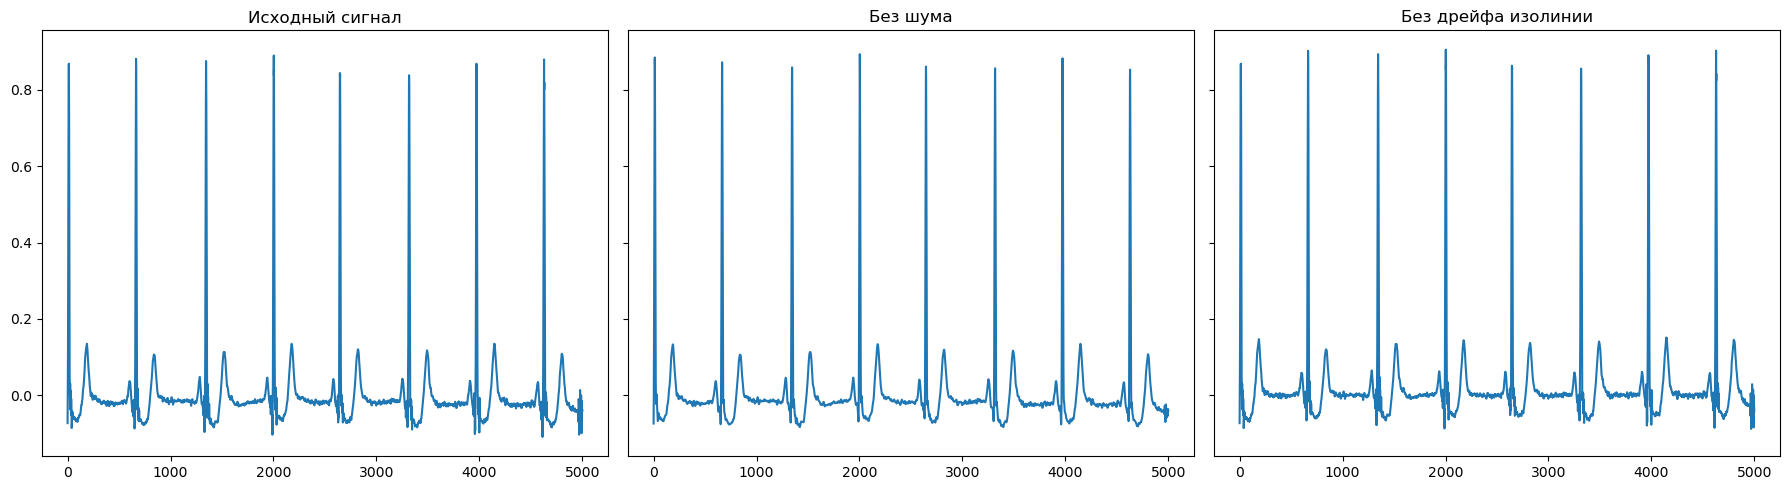

In [18]:
from scipy.signal import butter, filtfilt, medfilt

def remove_noise(signal, fs):
    """
    Удаление высокочастотного шума с помощью Butterworth filter.
    """

    # Магические числа из статьи
    cutoff = 50
    n = 5
    
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    
    b, a = butter(N=n, Wn=normal_cutoff, btype='low', analog=False)
    
    # Применяем фильтрацию в обе стороны (filtfilt), чтобы избежать фазового сдвига
    cleaned_signal = filtfilt(b, a, signal, axis=0)
    
    return cleaned_signal

def remove_baseline_wander(signal, fs):
    """
    Удаление дрейфа изолинии с помощью двух медианных фильтров.
    """
    
    # Размер окна должен быть нечетным числом для medfilt
    # Магические числа из статьи
    kernel_1 = int(0.2 * fs)
    if kernel_1 % 2 == 0: kernel_1 += 1
    
    kernel_2 = int(0.6 * fs)
    if kernel_2 % 2 == 0: kernel_2 += 1

    if signal.ndim > 1:
        # Для 2D массива задаем ядро как (длина_окна, 1)
        kernel_1 = [kernel_1, 1]
        kernel_2 = [kernel_2, 1]

    baseline_estimate = medfilt(signal, kernel_size=kernel_1)
    baseline_estimate = medfilt(baseline_estimate, kernel_size=kernel_2)
    
    # Вычитаем полученный тренд из оригинального сигнала
    detrended_signal = signal - baseline_estimate
    
    return detrended_signal

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].plot(record.p_signal)
axes[0].set_title("Исходный сигнал")

axes[1].plot(remove_noise(record.p_signal, record.fs))
axes[1].set_title("Без шума")

axes[2].plot(remove_baseline_wander(record.p_signal, record.fs))
axes[2].set_title("Без дрейфа изолинии")

plt.tight_layout()
plt.show()

In [162]:
def remove_border_labels(labels):
    # Делаем отступы при наличии сегментов с самого краю
    # # Левый край
    # l = 0
    # while labels[l] in [-100, 1, 2, 3]:
    #     labels[l] = -100
    #     l += 1
    
    # # Правый край
    # r = -1
    # while labels[r] in [-100, 1, 2, 3]:
    #     labels[r] = -100
    #     r -= 1

    labels_len = labels.shape[0]
    # 1. Находим активные сегменты (не фон и не игнор)
    is_active = (labels != 0) & (labels != -100)

    # 2. Индексы первого фона слева и справа для каждого канала
    first_bg = np.argmax(~is_active, axis=0)
    last_bg = labels_len - 1 - np.argmax(~is_active[::-1], axis=0)

    # 3. Создаём маску и применяем паддинг
    cols = np.arange(labels_len)
    labels[(cols < first_bg[None]) | (cols > last_bg[None])] = -100
    return labels

def create_windows(signal, labels, fs=500, window_seconds=2, overlap=0.5):
    """
    Нарезает сигнал и лейблы на фиксированные окна с перекрытием.
    
    :param signal: np.array (Length, channel)
    :param labels: np.array (channel, Length)
    :param fs: Частота дискретизации
    :param window_seconds: Размер окна в секундах
    :param overlap: Перекрытие между окнами (0.5 = 50%)
    :return: (windowed_signals, windowed_labels) - окна с перекрытием
              windowed_signals: (Num_windows, Window_size, channel)
              windowed_labels: (Num_windows, channel, Window_size)
    """
    window_size = int(window_seconds * fs)
    step_size = int(window_size * (1 - overlap))  # Шаг между окнами
    
    signal_len, channel = signal.shape
    
    # Вычисляем количество окон для одной записи
    # what in videcode is this
    num_windows = 0
    
    # Начинаем со смещения влево 
    start = -step_size
    while start + step_size <= signal_len:
        num_windows += 1
        start += step_size

    # Создаём выходные массивы
    windowed_signals = np.zeros((num_windows, window_size, channel))
    windowed_labels = np.full((num_windows, channel, window_size), -100)
    
    win_idx = 0
    start = -step_size
    
    while start + step_size <= signal_len:
        end = start + window_size
        
        # Если окно выходит за пределы сигнала - делаем паддинг
        if end > signal_len:
            pad_needed = end - signal_len
            
            # Паддинг сигнала
            window_sig = np.pad(signal[start:signal_len], ((0, pad_needed), (0, 0)), 
                               mode='constant', constant_values=0)
            # Паддинг лейблов
            window_lab = np.pad(labels[:, start:signal_len], ((0, 0), (0, pad_needed)), 
                               mode='constant', constant_values=-100)
        elif start < 0:
            pad_needed = -start
            
            # Паддинг сигнала
            window_sig = np.pad(signal[0:end], ((pad_needed, 0), (0, 0)), 
                               mode='constant', constant_values=0)
            # Паддинг лейблов
            window_lab = np.pad(labels[:, 0:end], ((0, 0), (pad_needed, 0)), 
                               mode='constant', constant_values=-100)
        else:
            window_sig = signal[start:end]
            window_lab = labels[:, start:end].copy()
        
        window_lab[0, ] = remove_border_labels(window_lab[0, ])
        
        windowed_signals[win_idx] = window_sig
        windowed_labels[win_idx] = window_lab
        
        win_idx += 1
        start += step_size
    
    return windowed_signals, windowed_labels

## Получаем данные
1. Загружаем все используемые датасеты
2. Предобрабатываем


In [20]:
from pathlib import Path

CHANNEL_MAPPING = {
    "i": 0,
    "ii": 1,
    "iii": 2,
    "avr": 3,
    "avl": 4,
    "avf": 5,
    "v1": 6,
    "v2": 7,
    "v3": 8,
    "v4": 9,
    "v5": 10,
    "v6": 11
}


def load_dataset(dataset_path, channel_names=['i'], annotation_ext=['i']):
    """
    Загружает первое отведение из всех WFDB записей в указанной директории.

    :dataset_path: Путь к папке с записями
    :channel_names: Названия каналов
    :annotation_ext: Расширения для считываемых аннотаций
    """

    channels = [CHANNEL_MAPPING[i] for i in channel_names]
    
    dataset_path = Path(dataset_path)
    
    hea_files = sorted(dataset_path.glob("*.hea"))

    records = []
    annotations = []
    for hea_path in hea_files:
        # Получаем путь к записи без расширения (нужно для wfdb)
        record_base_path = str(hea_path.with_suffix(''))

        record = wfdb.rdrecord(record_base_path, channels=channels)
        records.append(record)

        curr_rec_annotaiton = {}
        for c in annotation_ext:
            annotation = wfdb.rdann(record_base_path, c)
            curr_rec_annotaiton[c] = annotation

        annotations.append(curr_rec_annotaiton)
            
    return records, annotations

records, annotations = [], []
records_ludb, annotations_ludb = load_dataset("physionet.org/files/ludb/1.0.1/data/")

records += records_ludb
annotations += annotations_ludb

records, annotations

([<wfdb.io.record.Record at 0x1f60112fc50>,
 [{'i': <wfdb.io.annotation.Annotation at 0x1f60112fd90>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f601188550>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f60104da70>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f60104d940>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f67f790a70>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f67f9aee00>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f600ff2e00>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f67f903e50>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f60104a450>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f601067890>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f601067c50>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f601127310>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f6011273f0>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f601008a10>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f67fa82c90>},
  {'i': <wfdb.io.annotation.Annotation at 0x1f67fa81250>},
  {'i': <wfd

---

In [21]:
# А зачем, если для стабильной работы нейронки она должна всегда получать сигналы одной частоты 
def get_highest_fs(recrods):
    """
    Получаем частоту дискретизации, к которой будем приводить. 
    """

    all_fs = [base[0].fs for base in records]
    return max(all_fs)

# highest_fs = get_highest_fs(records)

# В основном 500 - самая высокая частота 
# (не считая *Leipzig Heart Center ECG-Database Arrhythmias in Children and Patients with Congenital Heart Disease*)
highest_fs = 500
highest_fs

500

In [22]:
from IPython.display import clear_output

def preprocess_signals(records, highest_fs=500):
    signals = []

    _log_cnt = 1
    for record in records:
        ########## LOG_START ##########
        clear_output(wait=True)
        print(f"LOG: Обработка записи {_log_cnt} из {len(records)}")
        ########## LOG_END ##########

        # Меняем частоту дискретизации
        signal = upsample_record(record.p_signal, record.fs, target_fs=highest_fs)

        # Шумы и изолиния
        signal = remove_baseline_wander(signal, highest_fs)
        signal = remove_noise(signal, highest_fs)

        signals.append(signal)
        
        _log_cnt += 1
    
    return np.array(signals)

signals = preprocess_signals(records)

LOG: Обработка записи 200 из 200


In [23]:
def preprocess_labels(annotations, signals, highest_fs=500):
    signals_len = [len(sig) for sig in signals]

    labels = []
    for annotation, sig_len in zip(annotations, signals_len):
        label = []
    
        for channel_annotation in annotation.values():
            upsampled_annotation = upsample_annotation(channel_annotation, target_fs=highest_fs)
            label.append(get_labels(upsampled_annotation, sig_len))
        
        labels.append(label)

    return np.array(labels)

labels = preprocess_labels(annotations, signals)
print(labels)

[[[-100 -100 -100 ... -100 -100 -100]]

 [[-100 -100 -100 ... -100 -100 -100]]

 [[-100 -100 -100 ... -100 -100 -100]]

 ...

 [[-100 -100 -100 ... -100 -100 -100]]

 [[-100 -100 -100 ... -100 -100 -100]]

 [[-100 -100 -100 ... -100 -100 -100]]]


Вырезаем первые и последние **две секунды** в каждом сигнале (неаннотированы; может, результат станет лучше).

In [24]:
# частота дискретизации - 500 всегда
# start_idx = 1000
# end_idx = -1000
# 
# signals = signals[:, start_idx:end_idx]
# labels = labels[:, :, start_idx:end_idx]
signals.shape, labels.shape

((200, 5000, 1), (200, 1, 5000))

In [25]:
signals_windowed = []
labels_windowed = []


for signal, label in zip(signals, labels):
    signal_w, label_w = create_windows(signal, label, window_seconds=3)
    signals_windowed.append(signal_w)
    labels_windowed.append(label_w)


signals_windowed = np.concatenate(signals_windowed, axis=0)
labels_windowed = np.concatenate(labels_windowed, axis=0)

signals_windowed, labels_windowed

(array([[[ 0.00000000e+00],
         [ 0.00000000e+00],
         [ 0.00000000e+00],
         ...,
         [-5.83639089e-02],
         [-5.81483534e-02],
         [-5.80077763e-02]],
 
        [[-7.44702630e-02],
         [-4.18767768e-02],
         [ 1.91846556e-03],
         ...,
         [ 6.34857747e-02],
         [ 6.85290389e-02],
         [ 7.36097768e-02]],
 
        [[-5.79106391e-02],
         [-5.77760292e-02],
         [-5.75183301e-02],
         ...,
         [ 3.81766974e-03],
         [ 4.46149429e-03],
         [ 4.87886816e-03]],
 
        ...,
 
        [[-2.34185956e-04],
         [-1.56512691e-04],
         [-5.18399512e-05],
         ...,
         [-1.59717389e-02],
         [-1.57925816e-02],
         [-1.45840525e-02]],
 
        [[ 5.20979854e-02],
         [ 5.44056207e-02],
         [ 5.74582850e-02],
         ...,
         [ 1.48340872e-02],
         [ 1.54405858e-02],
         [ 1.48285911e-02]],
 
        [[-1.25435342e-02],
         [-1.00678173e-02],
    

## Класс датасета

In [26]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.utils import shuffle

class SegmentationDataset(Dataset):
    def __init__(self, signals, labels, record_names, info=None):
        """
        :param signals: numpy-массивов (M х N), где M - длина, N - кол-во каналов
        :param labels: Список словарей с лейблами
        :param info: Список диагнозов по сигналам
        """
        self.signals = signals
        self.labels = labels

        self.info = info if info else [''] * self.signals.shape[0]

        self.record_names = record_names

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        sig = self.signals[idx]
        lab = self.labels[idx]
        
        # Conv1D в PyTorch ожидает формат (Channels, Length)
        x = torch.from_numpy(sig).float().permute(1, 0) 
        
        # Для CrossEntropyLoss
        y = torch.from_numpy(lab).long()
        y = y.squeeze()

        return x, y
    
    def dataset_to_windows(self, window_seconds=3):
        fs = 500
        if window_seconds >= self.signals.shape[1] * fs:
            return

        signals_windowed = []
        labels_windowed = []
        names_windowed = []

        for signal, label, name in zip(self.signals, self.labels, self.record_names):
            signal_w, label_w = create_windows(signal, label, window_seconds=window_seconds, overlap=0.5)
            signals_windowed.append(signal_w)
            labels_windowed.append(label_w)

            windows_num = len(signal_w)
            names_windowed += [name] * windows_num


        signals_windowed = np.concatenate(signals_windowed, axis=0)
        labels_windowed = np.concatenate(labels_windowed, axis=0)

        signals_windowed, labels_windowed, names_windowed = shuffle(signals_windowed, 
                                                                labels_windowed,
                                                                names_windowed,
                                                                random_state=42)
        
        return SegmentationDataset(signals_windowed, labels_windowed, names_windowed)

    # В отдельной функции, т.к. это требуется не так часто, как (x, y)
    def get_info(self, idx):
        return self.info[idx]
    
    def get_name(self, idx):
        return self.record_names[idx]

info = [r.comments for r in records]
names = [r.record_name for r in records]
dataset = SegmentationDataset(signals, labels, names, info)
dataset[0]

(tensor([[-0.0745, -0.0419,  0.0019,  ..., -0.0285, -0.0337, -0.0412]]),
 tensor([-100, -100, -100,  ..., -100, -100, -100]))

In [27]:
from sklearn.model_selection import train_test_split

def split_dataset(signals, labels, names=None, info=None, val_size=0.1, test_size=0.1):
    """
    Разделяет данные на Train, Val и Test и создает DataLoader для каждого.
    
    :param signals: Все окна сигналов (N, L, C)
    :param labels: Все окна лейблов (N, L)
    :param info: Комментарии к записи
    :param test_size: Доля тестовых данных (от общего объема)
    :param val_size: Доля валидационных данных (от общего объема)
    """

    if info == None:
        info = [None for i in range(signals.shape[0])]

    if names == None:
        names = [None for i in range(signals.shape[0])]
    # Отделяем тестовую выборку от всего объема
    train_val_sig, test_sig, train_val_lab, test_lab, train_val_name, test_name, train_val_info, test_info = train_test_split(
        signals, labels, names, info, test_size=test_size, random_state=42
    )
    
    # Поскольку берем val_size от неполной выборки, его надо пересчитать
    relative_val_size = val_size / (1.0 - test_size)
    
    train_sig, val_sig, train_lab, val_lab, train_name, val_name, train_info, val_info = train_test_split(
        train_val_sig, train_val_lab, train_val_name, train_val_info, test_size=relative_val_size, random_state=42
    )

    train_dataset = SegmentationDataset(train_sig, train_lab, train_name, train_info)
    val_dataset   = SegmentationDataset(val_sig, val_lab, val_name, val_info)
    test_dataset  = SegmentationDataset(test_sig, test_lab, test_name, test_info)
    
    return train_dataset, val_dataset, test_dataset


def prepare_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=32):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader


# Старая версия
train_dataset, val_dataset, test_dataset = split_dataset(signals_windowed, labels_windowed)
train_loader, val_loader, test_loader = prepare_dataloaders(train_dataset, val_dataset, test_dataset, 8)

print(f"Загрузка завершена:")
print(f"Train: {len(train_dataset)} окон")
print(f"Val:   {len(val_dataset)} окон")
print(f"Test:  {len(test_dataset)} окон")

Загрузка завершена:
Train: 1120 окон
Val:   140 окон
Test:  140 окон


In [28]:
info = [r.comments for r in records]
names = [r.record_name for r in records]

train_dataset, val_dataset, test_dataset = split_dataset(signals, labels, names, info)

# Для обучения делим на окна, для теста - нет
train_dataset = train_dataset.dataset_to_windows()
val_dataset = val_dataset.dataset_to_windows()

train_loader, val_loader, test_loader = prepare_dataloaders(train_dataset, val_dataset, test_dataset, 8)


print(f"Загрузка завершена:")
print(f"Train: {len(train_dataset)} окон")
print(f"Val:   {len(val_dataset)} окон")
print(f"Test:  {len(test_dataset)} окон")

Загрузка завершена:
Train: 1120 окон
Val:   140 окон
Test:  20 окон


# Модель
Реализация частично взята с https://github.com/ckjoung/ecg-segmentation. Код немного не соответствует статье, делаем как в статье. Доп. референс: 10.1109/ICASSP40776.2020.9053405

Пока попробуем без ветви классификации.

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=1.0, ignore_index=-100):
        super().__init__()
        self.gamma = gamma
        self.ignore_index = ignore_index
        
    def forward(self, input, target):
        '''
        input x: (B,C,N)
        target y: (B,N)
        CE_loss -log(y_pred): (B,N)
        y_pred: (B,N)
        '''
        CE_loss = F.cross_entropy(input, target, reduction='none', ignore_index=self.ignore_index)

        # 2. Создаем маску валидных позиций
        valid_mask = (target != self.ignore_index)
        
        # 3. Если все позиции игнорируются, возвращаем 0
        if not valid_mask.any():
            return torch.tensor(0.0, device=input.device)
        
        # 4. Вычисляем Focal Loss только для валидных позиций
        y_pred = torch.exp(-CE_loss)
        focal_loss = (1 - y_pred) ** self.gamma * CE_loss
        
        # 5. Применяем маску и усредняем по ВАЛИДНЫМ позициям
        focal_loss = focal_loss[valid_mask]
        return focal_loss.mean()

        y_pred = torch.exp(-CE_loss)
        focal_loss = torch.mean((1 - y_pred) ** self.gamma * CE_loss)
        

        
        return focal_loss

In [30]:
class ConvBnRelu1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=9, padding=4):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.LeakyReLU()
        self.do = nn.Dropout1d(0.2)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.do(x)
        return x


class StackEncoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=9, padding=4):
        super().__init__()
        self.conv1 = ConvBnRelu1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)
        self.conv2 = ConvBnRelu1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding)
        
        # Вот это уменьшает временную размерность в два раза
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return x, self.pool(x)

class StackDecoder(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, kernel_size=9, padding=4):
        super().__init__()
        # Получаем выходы блоков (приводим их к одной размерности)
        self.prep1 = nn.Conv1d(in_channels[0], skip_channels, kernel_size=kernel_size, padding=padding)
        self.prep2 = nn.Conv1d(in_channels[1], skip_channels, kernel_size=kernel_size, padding=padding)
        self.prep3 = nn.Conv1d(in_channels[2], skip_channels, kernel_size=kernel_size, padding=padding)
        self.prep4 = nn.Conv1d(in_channels[3], skip_channels, kernel_size=kernel_size, padding=padding)
        self.prep5 = nn.Conv1d(in_channels[4], skip_channels, kernel_size=kernel_size, padding=padding)
        
        # Сам декодер
        self.conv1 = ConvBnRelu1d(skip_channels * 5, out_channels, kernel_size=kernel_size, padding=padding)
        self.conv2 = ConvBnRelu1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding)

    def forward(self, x1, x2, x3, x4, x5):
        x1 = self.prep1(x1)
        x2 = self.prep2(x2)
        x3 = self.prep3(x3)
        x4 = self.prep4(x4)
        x5 = self.prep5(x5)

        x = torch.cat((x1, x2, x3, x4, x5), dim=1)  # concatenate along channel dimension
        x = self.conv1(x) 
        x = self.conv2(x) 
        return x

class ECGUNet(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__()

        filters = [n_channels * (2 ** n) for n in range(5)]  # Кол-во каналов на выходе каждого Encoder Block
        filters_skip = n_channels  # n_filters for skip connections
        filters_decoder = n_channels * 5  # n_filters for decoder feature maps

        self.down1 = StackEncoder(1, filters[0])
        self.down2 = StackEncoder(filters[0], filters[1])
        self.down3 = StackEncoder(filters[1], filters[2])
        self.down4 = StackEncoder(filters[2], filters[3])
        self.middle = nn.Sequential(ConvBnRelu1d(filters[3], filters[4]), ConvBnRelu1d(filters[4], filters[4]))

        self.up4 = StackDecoder(filters, filters_skip, filters_decoder)
        self.up3 = StackDecoder(filters[:3] + [filters_decoder] * 1 + filters[4:], filters_skip, filters_decoder)
        self.up2 = StackDecoder(filters[:2] + [filters_decoder] * 2 + filters[4:], filters_skip, filters_decoder)
        self.up1 = StackDecoder(filters[:1] + [filters_decoder] * 3 + filters[4:], filters_skip, filters_decoder)
        self.segment = nn.Conv1d(filters_decoder, 4, kernel_size=1, padding=0)

    def forward(self, x):
        # Энкодер; результат без макспулинга сохраняем для скип-коннекшнс,
        # а результаты с макспулингом передаем дальше
        X_enc1, x = self.down1(x)
        X_enc2, x = self.down2(x)
        X_enc3, x = self.down3(x)
        X_enc4, x = self.down4(x)
        X_enc5 = self.middle(x)

        # decoder
        X_dec5 = X_enc5
        X_dec4 = self.up4(
            F.max_pool1d(X_enc1, kernel_size=8, stride=8),
            F.max_pool1d(X_enc2, kernel_size=4, stride=4),
            F.max_pool1d(X_enc3, kernel_size=2, stride=2),
            X_enc4,
            F.interpolate(X_dec5, size=X_enc4.shape[-1], mode='linear', align_corners=False)
        )
        X_dec3 = self.up3(
            F.max_pool1d(X_enc1, kernel_size=4, stride=4),
            F.max_pool1d(X_enc2, kernel_size=2, stride=2),
            X_enc3,
            F.interpolate(X_dec4, size=X_enc3.shape[-1], mode='linear', align_corners=False),
            F.interpolate(X_dec5, size=X_enc3.shape[-1], mode='linear', align_corners=False)
        )
        X_dec2 = self.up2(
            F.max_pool1d(X_enc1, kernel_size=2, stride=2),
            X_enc2,
            F.interpolate(X_dec3, size=X_enc2.shape[-1], mode='linear', align_corners=False),
            F.interpolate(X_dec4, size=X_enc2.shape[-1], mode='linear', align_corners=False),
            F.interpolate(X_dec5, size=X_enc2.shape[-1], mode='linear', align_corners=False)
        )
        X_dec1 = self.up1(
            X_enc1,
            F.interpolate(X_dec2, size=X_enc1.shape[-1], mode='linear', align_corners=False),
            F.interpolate(X_dec3, size=X_enc1.shape[-1], mode='linear', align_corners=False),
            F.interpolate(X_dec4, size=X_enc1.shape[-1], mode='linear', align_corners=False),
            F.interpolate(X_dec5, size=X_enc1.shape[-1], mode='linear', align_corners=False)
        )
        return self.segment(X_dec1)
    
model = ECGUNet()


## Обучение

In [31]:
def train(model, device, train_loader, loss_function, optimizer):
    model.train()
    train_loss = 0

    n_train = len(train_loader.dataset)

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        y_pred = model(x)

        # loss calculation and backprop
        optimizer.zero_grad()
        loss = loss_function(y_pred, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(x)

    train_loss /= n_train

    return train_loss


def test(model, device, test_loader, loss_function):
    model.eval()
    test_loss = 0

    n_test = len(test_loader.dataset)

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)

            loss = loss_function(y_pred, y)

            test_loss += loss.item() * len(x)
        
        test_loss /= n_test

    return test_loss

In [32]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [71]:
# Progress bar
from tqdm.auto import tqdm
model = ECGUNet().to(device)

epochs = 100

loss_function = FocalLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

# Раз в n эпох выводим статистику
print_interval = 20

pbar = tqdm(range(epochs), desc="Training Progress")

train_losses = []
val_losses = []

for epoch in pbar:
    train_loss = train(model, 
                       device, 
                       train_loader, 
                       loss_function, 
                       optimizer)
    val_loss = test(model, 
                    device, 
                    val_loader, 
                    loss_function)
    
    # --- Обновляем прогресс-бар ---
    current_lr = optimizer.param_groups[0]['lr']
    pbar.set_postfix({
        'train_loss': f'{train_loss:.4f}',
        'val_loss': f'{val_loss:.4f}',
        'lr': f'{current_lr:.6f}'
    })

    # --- Вывод статистики каждые n эпох ---
    if epoch % print_interval == 0:
        tqdm.write(f"\n{'=' * 60}")
        tqdm.write(f"Epoch {epoch:3d}/{epochs}")
        tqdm.write(f"{'=' * 60}")
        tqdm.write(f"  Train Loss: {train_loss:.4f}")
        tqdm.write(f"  Val Loss:   {val_loss:.4f}")
        tqdm.write(f"  LR:         {current_lr:.6f}")
        tqdm.write(f"{'=' * 60}\n")
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step()

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]


Epoch   0/100
  Train Loss: 0.6108
  Val Loss:   0.4915
  LR:         0.001000


Epoch  20/100
  Train Loss: 0.1707
  Val Loss:   0.1734
  LR:         0.000905


Epoch  40/100
  Train Loss: 0.1513
  Val Loss:   0.1485
  LR:         0.000658


Epoch  60/100
  Train Loss: 0.1457
  Val Loss:   0.1441
  LR:         0.000352


Epoch  80/100
  Train Loss: 0.1419
  Val Loss:   0.1380
  LR:         0.000105



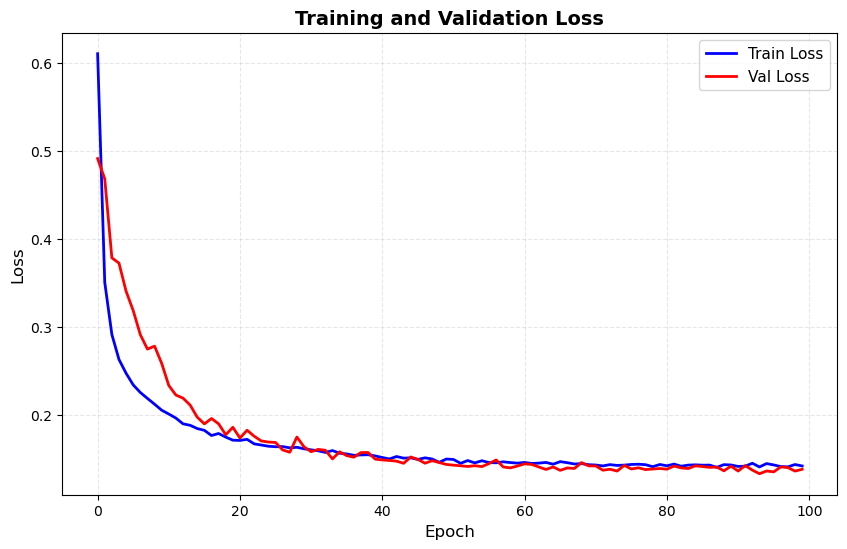

In [72]:
import matplotlib.pyplot as plt

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(val_losses, 'r-', label='Val Loss', linewidth=2)

# Оформление
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')

plt.show()

## Оценка

In [33]:
# torch.save(model.state_dict(), 'models\ecg_model_100e_sliding_3s.pth')
model = ECGUNet()
model.load_state_dict(
        torch.load(
        r'models\ecg_model_100e_sliding_3s.pth'
    )
)

<All keys matched successfully>

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Optional
import seaborn as sns
from collections import Counter


def labels_to_segments(labels: np.ndarray, ignore_index: int = -100) -> Tuple[List[int], List[Tuple[int, int]]]:
    """
    Конвертирует массив меток в список классов и их границ (onset, offset).
    Области со значением ignore_index полностью игнорируются.
    """

    classes, boundaries = [], []
    # labels = remove_border_labels(labels)

    # Находим границы изменений класса
    diff = np.diff(labels.astype(int))
    changes = np.where(diff != 0)[0] + 1
    
    # Добавляем начало и конец
    segment_starts = np.r_[0, changes]
    segment_ends = np.r_[changes, len(labels)]
    
    for start, end in zip(segment_starts, segment_ends):
        cls = labels[start]
        # Пропускаем игнорируемые значения и фон (0)
        if cls == ignore_index or cls == 0:
            continue
        classes.append(int(cls))
        boundaries.append((start, end))
    
    return classes, boundaries


def match_segments(
    true_classes: List[int],
    true_bounds: List[Tuple[int, int]],
    pred_classes: List[int],
    pred_bounds: List[Tuple[int, int]],
    tolerance_samples: int
) -> Dict[str, List[Tuple[int, int]]]:
    """
    Сопоставляет предсказанные сегменты с истинными.
    
    Сопоставление происходит только если:
    1. Классы сегментов совпадают (P-P, QRS-QRS, T-T)
    2. Ошибка по onset/offset в пределах tolerance
    
    Returns: {'TP': [...], 'FP': [...], 'FN': [...]}
        TP - совпавшие пары
        FP - ложные срабатывания
        FN - пропущенные сегменты
    """

    TP = []
    FP = []
    FN = []

    # Какие из настоящих лейблов нашли (даже если неправильно)
    found_true = []
    for pred_cls, (pred_onset, pred_offset) in zip(pred_classes, pred_bounds):
        best_error = tolerance_samples * 2
        
        # Формат: (true_cls, pred_cls)
        best_match = None

        for true_cls, (true_onset, true_offset) in zip(true_classes, true_bounds):

            # Перебор
            if true_onset - pred_onset > tolerance_samples or true_offset - pred_offset > tolerance_samples:
                break
            
            if abs(true_onset - pred_onset) < tolerance_samples and abs(true_offset - pred_offset) < tolerance_samples:
                error = abs(true_onset - pred_onset) + abs(true_offset - pred_offset)
                if error <= best_error:
                    best_error = error
                    best_match = (true_cls, pred_cls)

        if best_match != None:
            found_true.append(best_match[0])
            if best_match[0] == best_match[1]:
                TP.append(best_match)
            else:
                FP.append(best_match)
        else:
            FP.append((0, pred_cls))

    # Получаем список классов, которых не было в предсказанных, но были в действительных
    diff = Counter(true_classes) - Counter(found_true)
    FN = [(e, 0) for e in diff.elements()]

    return {'TP': TP, 'FP': FP, 'FN': FN}

def calculate_ecg_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sampling_rate: int = 500,
    tolerance_ms: int = 150,
    ignore_index: int = -100
) -> Dict[str, Dict[str, float]]:
    """Вычисляет метрики сегментации ЭКГ (F1, Se, PPV) через match_segments.
    
    Области со значением ignore_index (-100) игнорируются при расчёте.
    """
    
    tolerance_samples = int(tolerance_ms * sampling_rate / 1000)

    mask = y_true != -100

    # 1. Конвертация в сегменты (игнорируемые области пропускаются)
    true_classes, true_bounds = labels_to_segments(y_true * mask, ignore_index)
    pred_classes, pred_bounds = labels_to_segments(y_pred * mask, ignore_index)
    
    # 2. Сопоставление сегментов
    matches = match_segments(true_classes, true_bounds, pred_classes, pred_bounds, tolerance_samples)
    # 3. Подсчёт TP/FP/FN по классам
    class_names = {1: 'P_wave', 2: 'QRS', 3: 'T_wave'}
    results = {}
    
    for cls in [1, 2, 3]:
        tp = sum(1 for t in matches['TP'] if t[0] == cls)
        fp = sum(1 for f in matches['FP'] if f[1] == cls)
        fn = sum(1 for f in matches['FN'] if f[0] == cls)
        
        se = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = 2 * se * ppv / (se + ppv) if (se + ppv) > 0 else 0.0
        

        results[class_names[cls]] = {
            'F1': f1, 'Sensitivity': se, 'PPV': ppv,
            'TP': tp, 'FP': fp, 'FN': fn
        }
    
    return results


def build_confusion_matrix_from_matches(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sampling_rate: int = 500,
    tolerance_ms: int = 150,
    ignore_index: int = -100,
    class_names: Optional[List[str]] = None,
    figsize: Tuple[int, int] = (8, 6),
) -> plt.Figure:
    """Строит матрицу ошибок на основе match_segments."""
    
    if class_names is None:
        class_names = ['P wave', 'QRS', 'T wave']

    tolerance_samples = int(tolerance_ms * sampling_rate / 1000)
    
    mask = y_true != -100

    pred_classes, pred_bounds = labels_to_segments(y_pred * mask, ignore_index)
    true_classes, true_bounds = labels_to_segments(y_true * mask, ignore_index)
    
    matches = match_segments(true_classes, true_bounds, pred_classes, pred_bounds, tolerance_samples)
    
    # Матрица 4x4: 0=фон, 1=P, 2=QRS, 3=T
    cm = np.zeros((4, 4), dtype=int)

    for (true_cls, pred_cls) in matches['TP']:
        cm[true_cls, pred_cls] += 1
    
    for (true_cls, pred_cls) in matches['FP']:
        cm[true_cls, pred_cls] += 1
    
    for (true_cls, pred_cls) in matches['FN']:
        cm[true_cls, pred_cls] += 1
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Background'] + class_names,
                yticklabels=['Background'] + class_names,
                ax=ax, cbar_kws={'label': 'Count'})
    
    ax.set_xlabel('Predicted Segments', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Segments', fontsize=12, fontweight='bold')
    ax.set_title('Segment-Level Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    
    return fig
        

In [189]:
model.to('cpu')
# 1. Получаем данные из датасета
x, y_true = test_dataset[2]  # x: (C, L), y_true: (L,)

# 2. Добавляем batch dimension для модели
x_batch = x.unsqueeze(0) # (1, C, L)

# 3. Предсказание модели
with torch.no_grad():
    y_pred = model(x_batch)  # seg_output: (1, 4, L)
    y_pred = torch.argmax(y_pred, dim=1).squeeze(0).cpu().numpy()  # (L,)

calculate_ecg_metrics(y_true.numpy(), y_pred)

{'P_wave': {'F1': 1.0,
  'Sensitivity': 1.0,
  'PPV': 1.0,
  'TP': 8,
  'FP': 0,
  'FN': 0},
 'QRS': {'F1': 1.0, 'Sensitivity': 1.0, 'PPV': 1.0, 'TP': 9, 'FP': 0, 'FN': 0},
 'T_wave': {'F1': 1.0,
  'Sensitivity': 1.0,
  'PPV': 1.0,
  'TP': 8,
  'FP': 0,
  'FN': 0}}

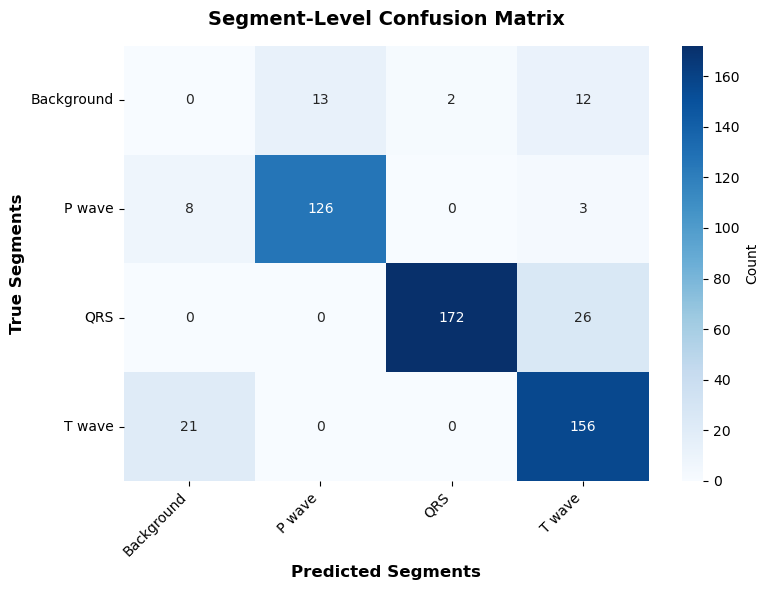

In [190]:
model.to(device)

# Для всего тестового набора
all_true_segments, all_pred_segments = [], []
for x, y in test_dataset:
    with torch.no_grad():
        x = x.unsqueeze(0).to(device)
        seg_output = model(x)
        y_pred = torch.argmax(seg_output, dim=1).cpu().numpy().squeeze()
    y_true = y.squeeze().numpy()

    all_true_segments.append(y_true)
    all_pred_segments.append(y_pred)

all_true_segments = np.concatenate(all_true_segments, axis=0)
all_pred_segments = np.concatenate(all_pred_segments, axis=0)

fig = build_confusion_matrix_from_matches(all_true_segments, all_pred_segments, tolerance_ms=100)
plt.show()

In [191]:
calculate_ecg_metrics(all_true_segments, all_pred_segments, tolerance_ms=100)

{'P_wave': {'F1': 0.9230769230769231,
  'Sensitivity': 0.9402985074626866,
  'PPV': 0.9064748201438849,
  'TP': 126,
  'FP': 13,
  'FN': 8},
 'QRS': {'F1': 0.9942196531791908,
  'Sensitivity': 1.0,
  'PPV': 0.9885057471264368,
  'TP': 172,
  'FP': 2,
  'FN': 0},
 'T_wave': {'F1': 0.8342245989304814,
  'Sensitivity': 0.8813559322033898,
  'PPV': 0.7918781725888325,
  'TP': 156,
  'FP': 41,
  'FN': 21}}

## Визуализация

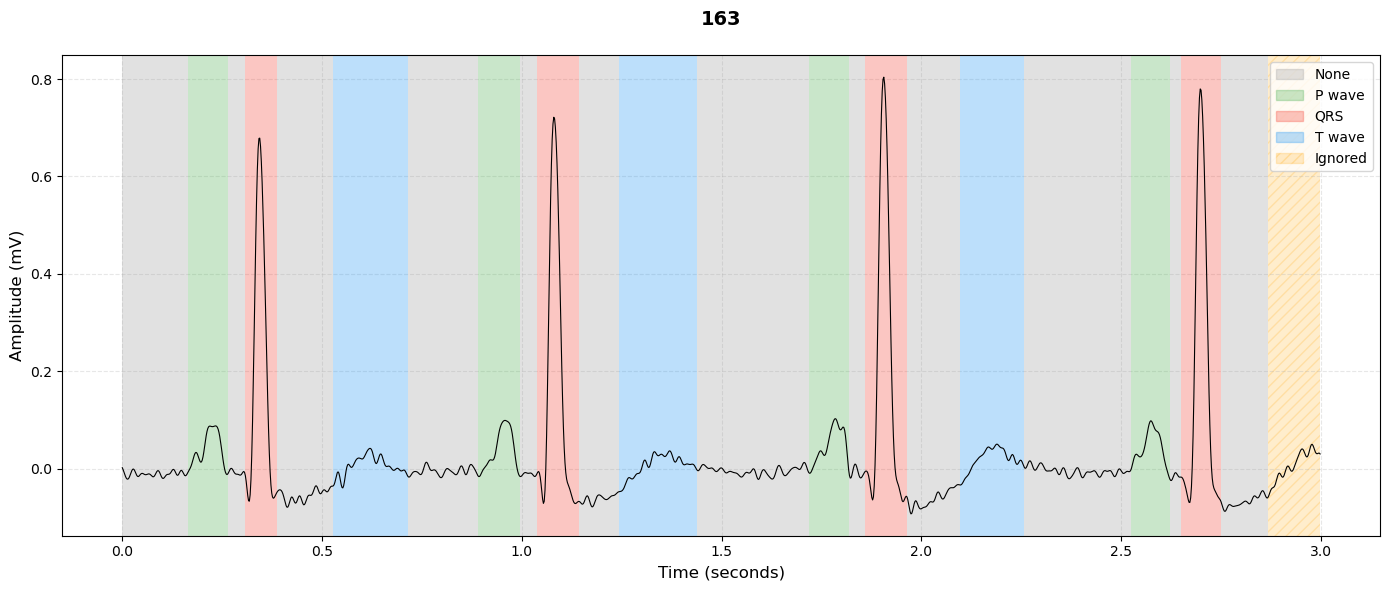

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import Optional, List, Tuple

def plot_ecg_segmentation(
    signal: np.ndarray,
    labels: np.ndarray,
    sampling_rate: int = 500,
    ignore_index: int = -100,
    title: Optional[str] = None,
    show_legend: bool = True,
    ax: Optional[plt.Axes] = None,
    figsize: Tuple[int, int] = (14, 4)
) -> plt.Figure:
    """
    Визуализирует сигнал ЭКГ с выделенными сегментами.
    
    Args:
        signal: Сигнал ЭКГ формы (L,) или (1, L)
        labels: Массив меток формы (L,)
        sampling_rate: Частота дискретизации в Гц (по умолчанию 500)
        ignore_index: Значение игнорируемых меток (по умолчанию -100)
        title: Заголовок графика
        show_legend: Показывать ли легенду
        ax: Ось matplotlib для рисования (если None, создаётся новая фигура)
        figsize: Размер фигуры (используется только если ax=None)
    
    Returns:
        Figure объект matplotlib
    """
    # Нормализация входных данных
    signal = np.asarray(signal).squeeze()
    labels = np.asarray(labels).squeeze()
    
    assert signal.shape[0] == labels.shape[0], "Длины сигнала и меток должны совпадать"
    
    # Создаём новую фигуру или используем предоставленную ось
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        create_new_fig = True
    else:
        fig = ax.get_figure()
        create_new_fig = False
    
    class_colors = {
        0: '#9E9E9E',    # None - серый
        1: '#4CAF50',    # P wave - зелёный
        2: '#F44336',    # QRS - красный
        3: '#2196F3',    # T wave - синий
        -100: '#FFFFFF'  # Ignore - белый
    }
    
    class_names = {
        0: 'None',
        1: 'P wave',
        2: 'QRS',
        3: 'T wave',
        -100: 'Ignored'
    }
    
    # Временная ось
    time = np.arange(len(signal)) / sampling_rate
    
    # Построение сигнала
    ax.plot(time, signal, 'k-', linewidth=0.8, label='ECG signal', zorder=10)
    
    # Выделение сегментов цветом
    for class_id in [0, 1, 2, 3]:
        mask = (labels == class_id)
        diff = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends = np.where(diff == -1)[0] + 1
        
        if mask[0]:
            starts = np.r_[0, starts]
        if mask[-1]:
            ends = np.r_[ends, len(mask)]
        
        for start, end in zip(starts, ends):
            end = min(end, len(time) - 1)
            start = min(start, len(time) - 1)
            ax.axvspan(
                time[start], time[end],
                color=class_colors[class_id],
                alpha=0.3,
                linewidth=0,
                zorder=1
            )
    
    # Выделение игнорируемых участков (штриховка)
    ignore_mask = (labels == ignore_index)
    if ignore_mask.any():
        diff = np.diff(ignore_mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends = np.where(diff == -1)[0] + 1
        
        if ignore_mask[0]:
            starts = np.r_[0, starts]
        if ignore_mask[-1]:
            ends = np.r_[ends, len(ignore_mask)]
        
        for start, end in zip(starts, ends):
            end = min(end, len(time) - 1)
            start = min(start, len(time) - 1)
            ax.axvspan(
                time[start], time[end],
                color='#FFA500',
                alpha=0.2,
                hatch='///',
                linewidth=0,
                zorder=0
            )
    
    # Настройка осей
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('Amplitude (mV)', fontsize=12)
    
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Легенда
    if show_legend:
        legend_elements = [
            Patch(facecolor=class_colors[0], alpha=0.3, edgecolor=class_colors[0], 
                  label=f'{class_names[0]}'),
            Patch(facecolor=class_colors[1], alpha=0.3, edgecolor=class_colors[1], 
                  label=f'{class_names[1]}'),
            Patch(facecolor=class_colors[2], alpha=0.3, edgecolor=class_colors[2], 
                  label=f'{class_names[2]}'),
            Patch(facecolor=class_colors[3], alpha=0.3, edgecolor=class_colors[3], 
                  label=f'{class_names[3]}'),
            Patch(facecolor='#FFA500', alpha=0.2, hatch='///', edgecolor='#FFA500',
                  label=f'{class_names[-100]}')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    if create_new_fig:
        plt.tight_layout()
    
    return fig

# Визуализация
fig = plot_ecg_segmentation(
    train_dataset[2][0], 
    train_dataset[2][1], 
    sampling_rate=500,
    title=f'{train_dataset.record_names[2] + '\n' + '\n'.join(train_dataset.info[2])}',
    figsize=(14,6)
)


plt.show()

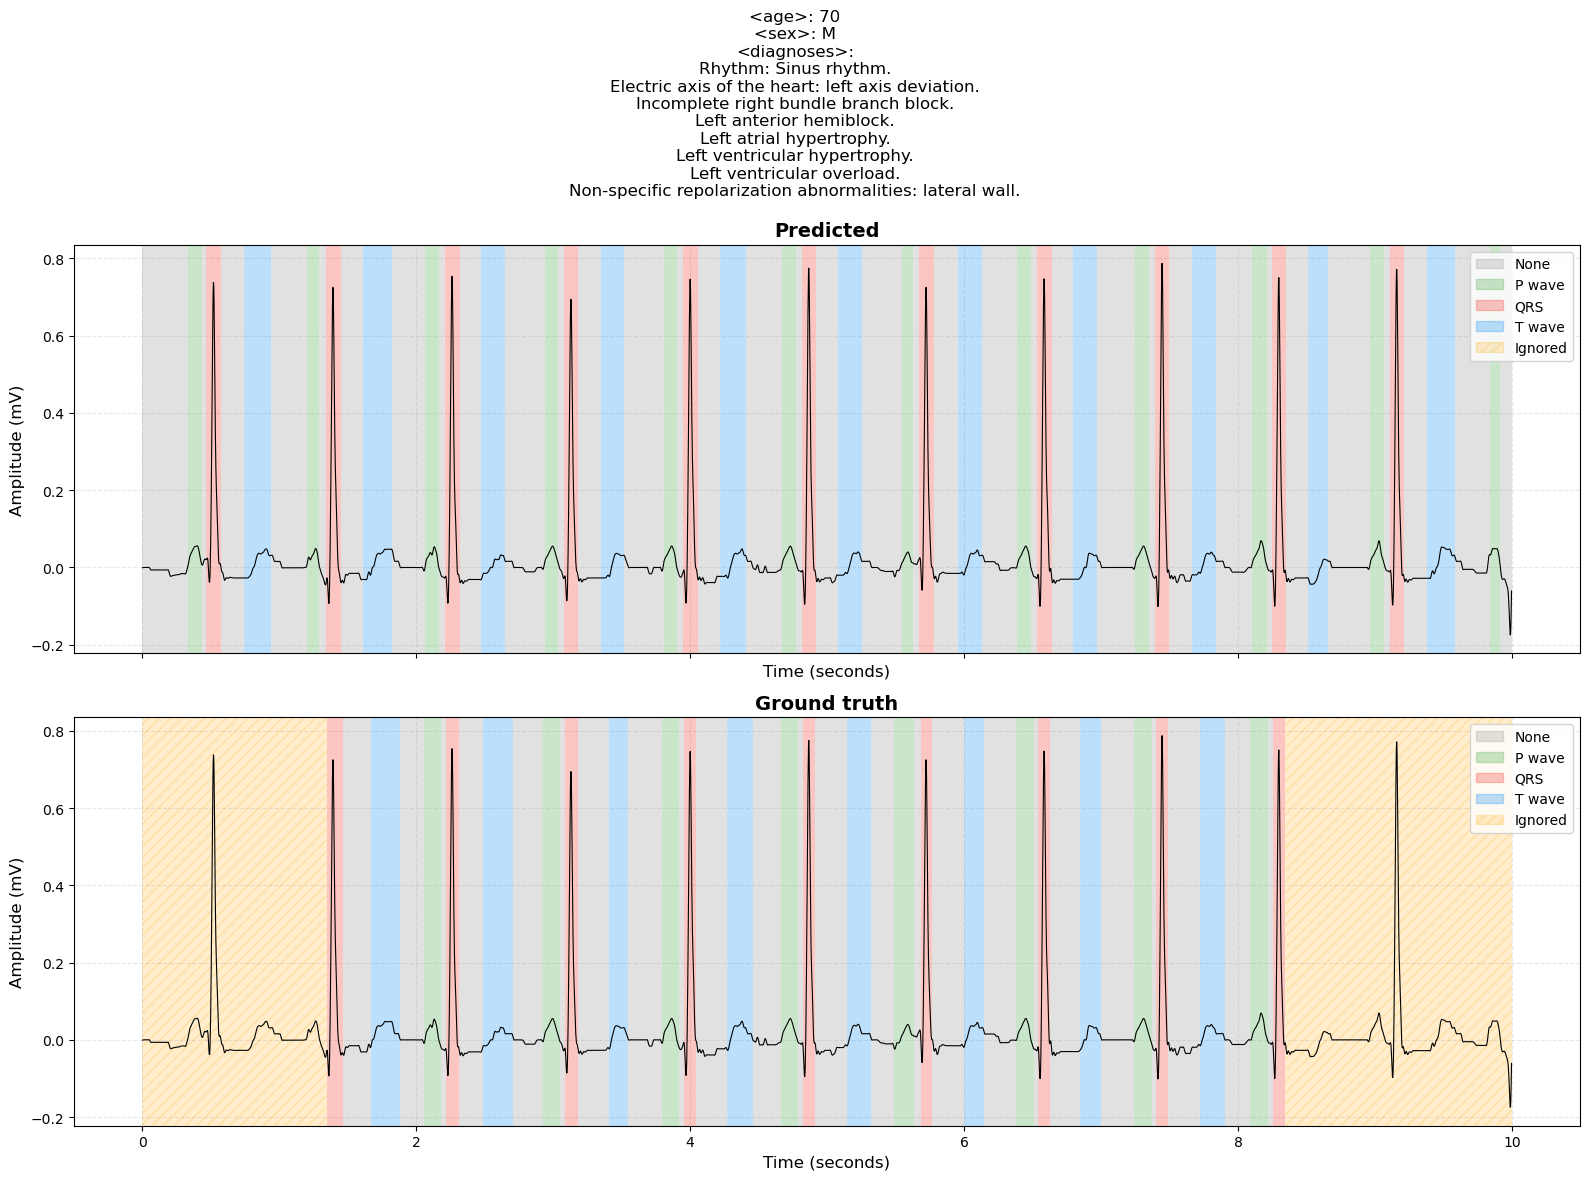

{'P_wave': {'F1': 1.0, 'Sensitivity': 1.0, 'PPV': 1.0, 'TP': 8, 'FP': 0, 'FN': 0}, 'QRS': {'F1': 1.0, 'Sensitivity': 1.0, 'PPV': 1.0, 'TP': 9, 'FP': 0, 'FN': 0}, 'T_wave': {'F1': 1.0, 'Sensitivity': 1.0, 'PPV': 1.0, 'TP': 8, 'FP': 0, 'FN': 0}}


In [80]:
model.to('cpu')
model.eval()

# 1. Получаем данные из датасета
x, y_true = test_dataset[2]  # x: (C, L), y_true: (L,)

# 2. Добавляем batch dimension для модели
x_batch = x.unsqueeze(0) # (1, C, L)

# 3. Предсказание модели
with torch.no_grad():
    y_pred = model(x_batch)  # seg_output: (1, 4, L)
    y_pred = torch.argmax(y_pred, dim=1).squeeze(0).cpu().numpy()  # (L,)

# 4. Сигнал для визуализации (numpy, форма (L,))
signal = x.squeeze().cpu().numpy()

# 5. Визуализация
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True, sharey=True)

plot_ecg_segmentation(
    signal, 
    y_pred, 
    sampling_rate=500,
    title='Predicted',
    ax=axes[0]
)

plot_ecg_segmentation(
    signal, 
    y_true, 
    sampling_rate=500,
    title='Ground truth',
    ax=axes[1]
)
fig.suptitle('\n'.join(test_dataset.get_info(2)) + '\n')
plt.tight_layout()

plt.show()

print(calculate_ecg_metrics(y_true.numpy(), y_pred))

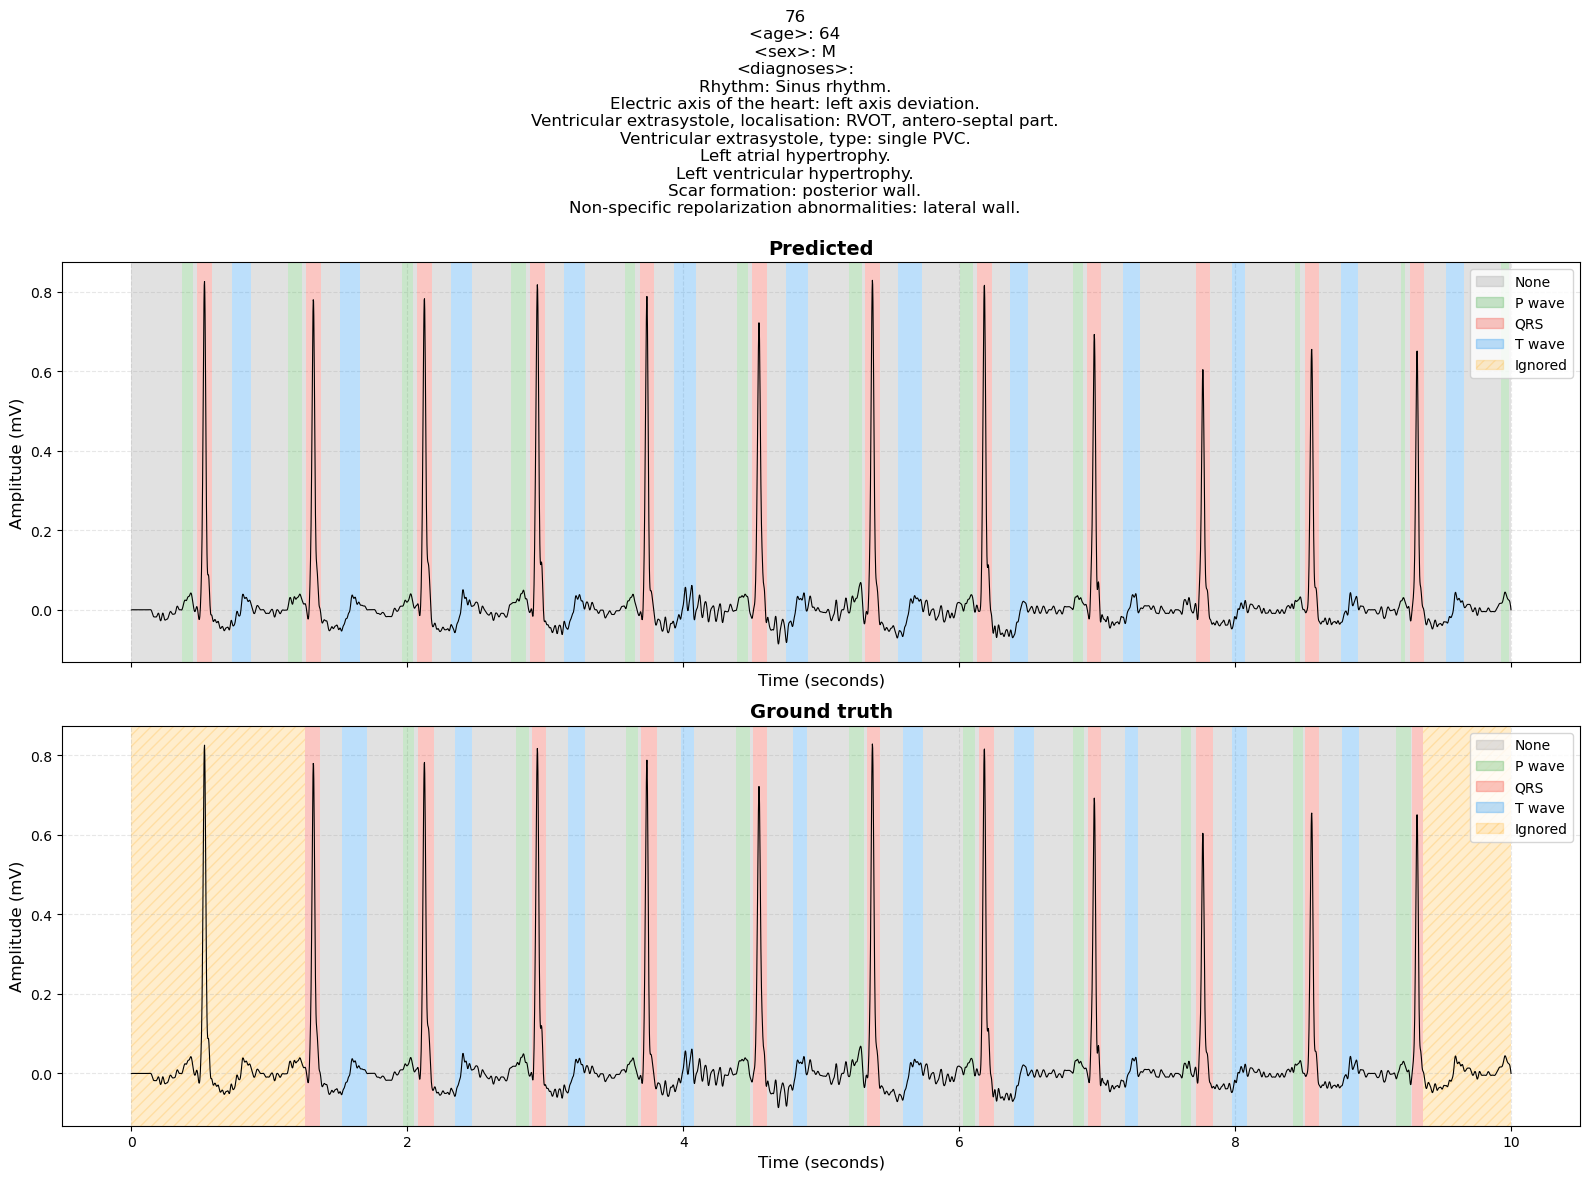

{'P_wave': {'F1': 0.9473684210526316, 'Sensitivity': 0.9, 'PPV': 1.0, 'TP': 9, 'FP': 0, 'FN': 1}, 'QRS': {'F1': 1.0, 'Sensitivity': 1.0, 'PPV': 1.0, 'TP': 11, 'FP': 0, 'FN': 0}, 'T_wave': {'F1': 1.0, 'Sensitivity': 1.0, 'PPV': 1.0, 'TP': 10, 'FP': 0, 'FN': 0}}


In [49]:
model.to('cpu')
model.eval()

idx = 8

# 1. Получаем данные из датасета
x, y_true = test_dataset[idx] # x: (C, L), y_true: (L,)

# 2. Добавляем batch dimension для модели
x_batch = x.unsqueeze(0) # (1, C, L)

# 3. Предсказание модели
with torch.no_grad():
    y_pred = model(x_batch)  # seg_output: (1, 4, L)
    y_pred = torch.argmax(y_pred, dim=1).squeeze(0).cpu().numpy()  # (L,)

# 4. Сигнал для визуализации (numpy, форма (L,))
signal = x.squeeze().cpu().numpy()

# 5. Визуализация
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True, sharey=True)

plot_ecg_segmentation(
    signal, 
    y_pred, 
    sampling_rate=500,
    title='Predicted',
    ax=axes[0]
)

plot_ecg_segmentation(
    signal, 
    y_true, 
    sampling_rate=500,
    title='Ground truth',
    ax=axes[1]
)
fig.suptitle(test_dataset.get_name(idx) + '\n' + '\n'.join(info[idx]) + '\n')
plt.tight_layout()

plt.show()

print(calculate_ecg_metrics(y_true.numpy(), y_pred))

In [192]:
import os

# Создаём директорию для сохранения ошибок
error_dir = 'error_samples'
os.makedirs(error_dir, exist_ok=True)

def find_error_samples(
    model, 
    dataset, 
    device='cpu',
    sampling_rate=500
):
    """
    Находит примеры, где модель допустила ошибки, и сохраняет их в PNG.
    
    Args:
        model: Обученная модель сегментации
        dataset: Тестовый датасет
        device: Устройство для вычислений
        max_errors: Максимальное количество сохраняемых примеров
        min_f1_threshold: Порог F1-меры для классификации как 'ошибка'
        sampling_rate: Частота дискретизации
    """
    model.to(device)
    model.eval()
    
    error_count = 0
    processed = 0
    
    for idx in range(len(dataset)):
        x, y_true = dataset[idx]
        x_batch = x.unsqueeze(0).to(device)
        
        with torch.no_grad():
            y_pred = model(x_batch)
            y_pred = torch.argmax(y_pred, dim=1).squeeze(0).cpu().numpy()
        
        y_true_np = y_true.numpy()
        
        # Вычисляем метрики
        metrics = calculate_ecg_metrics(y_true_np, 
                                        y_pred, 
                                        sampling_rate=sampling_rate,
                                        tolerance_ms=100)
        # Проверяем, есть ли ошибки (F1 < threshold или есть FP/FN)
        has_error = False
        worst_class = None
        worst_f1 = 1.0
        
        for cls_name, cls_metrics in metrics.items():
            if cls_metrics['FP'] > 0 or cls_metrics['FN'] > 0:
                print(cls_name, cls_metrics)
                has_error = True
                if cls_metrics['F1'] < worst_f1:
                    worst_f1 = cls_metrics['F1']
                    worst_class = cls_name
        
        if has_error:
            true_idx = dataset.record_names[idx]
            signal = x.squeeze().cpu().numpy()
            
            # Создаём сравнение predicted vs ground truth
            fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True, sharey=True)
            
            plot_ecg_segmentation(
                signal, y_pred, sampling_rate=sampling_rate,
                title=f'Predicted (Sample #{true_idx}, Class: {worst_class}, F1={worst_f1:.2f})',
                ax=axes[0]
            )
            
            plot_ecg_segmentation(
                signal, y_true_np, sampling_rate=sampling_rate,
                title='Ground truth',
                ax=axes[1]
            )
            
            fig.suptitle('\n'.join(dataset.get_info(idx)) + '\n')
            plt.tight_layout()
            
            # Формируем имя файла с метриками
            p_metrics = metrics.get('P_wave', {})
            qrs_metrics = metrics.get('QRS', {})
            t_metrics = metrics.get('T_wave', {})
            
            filename = (
                f"error_{true_idx}_"
                f"P_F1={p_metrics.get('F1', 0):.2f}_"
                f"QRS_F1={qrs_metrics.get('F1', 0):.2f}_"
                f"T_F1={t_metrics.get('F1', 0):.2f}.png"
            )
            
            filepath = os.path.join(error_dir, filename)
            plt.savefig(filepath, dpi=150, bbox_inches='tight')
            plt.close(fig)
            
            print(f"Saved: {filename}")
            error_count += 1
        
        processed += 1
        if processed % 50 == 0:
            print(f"Processed {processed}/{len(dataset)} samples, found {error_count} errors...")
    
    print(f"\nDone! Processed {processed} samples, saved {error_count} error examples to '{error_dir}/'")
    return error_count

# Запуск поиска ошибок
print("Searching for error samples...")
find_error_samples(
    model, 
    test_dataset, 
    device=device,
    sampling_rate=500
)

Searching for error samples...
P_wave {'F1': 0.0, 'Sensitivity': 0.0, 'PPV': 0.0, 'TP': 0, 'FP': 3, 'FN': 0}
T_wave {'F1': 0.9230769230769231, 'Sensitivity': 0.9230769230769231, 'PPV': 0.9230769230769231, 'TP': 12, 'FP': 1, 'FN': 1}
Saved: error_112_P_F1=0.00_QRS_F1=1.00_T_F1=0.92.png
T_wave {'F1': 0.125, 'Sensitivity': 0.125, 'PPV': 0.125, 'TP': 1, 'FP': 7, 'FN': 7}
Saved: error_61_P_F1=1.00_QRS_F1=1.00_T_F1=0.12.png
T_wave {'F1': 0.0, 'Sensitivity': 0.0, 'PPV': 0.0, 'TP': 0, 'FP': 8, 'FN': 7}
Saved: error_34_P_F1=0.00_QRS_F1=0.00_T_F1=0.00.png
P_wave {'F1': 0.64, 'Sensitivity': 0.8, 'PPV': 0.5333333333333333, 'TP': 8, 'FP': 7, 'FN': 2}
T_wave {'F1': 0.8000000000000002, 'Sensitivity': 0.8, 'PPV': 0.8, 'TP': 8, 'FP': 2, 'FN': 2}
Saved: error_22_P_F1=0.64_QRS_F1=1.00_T_F1=0.80.png
P_wave {'F1': 0.0, 'Sensitivity': 0.0, 'PPV': 0.0, 'TP': 0, 'FP': 0, 'FN': 4}
T_wave {'F1': 0.5384615384615384, 'Sensitivity': 1.0, 'PPV': 0.3684210526315789, 'TP': 7, 'FP': 12, 'FN': 0}
Saved: error_72_P_F1=0

9